In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import traceback # For detailed error printing

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge # Example alternative model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [2]:
# --- Load Data ---
data = pd.DataFrame() # Initialize empty dataframe
try:
    # Use the variable 'data' if it's already loaded from your previous cells
    print("Attempting to use pre-loaded data.")
    # The check 'if 'data' not in locals()' doesn't work well across cells sometimes.
    # We will rely on trying to load if the dataframe is empty after this block.
    # if 'data' not in locals() or data.empty: # Check if it exists and is not empty

    # Let's explicitly try loading if the initial check fails or wasn't done
    if data.empty:
         print("Pre-loaded data 'data' not found or empty. Attempting to load from file.")
         try:
             # *** IMPORTANT: Make sure this path is correct for your system ***
             data = pd.read_excel("social_media_engagement_data.xlsx")
             print(f"Loaded data from file. Shape: {data.shape}")
         except FileNotFoundError:
             print("Error: Excel file 'social_media_engagement_data.xlsx' not found.")
             print("Please ensure the file exists in the same directory as the notebook or provide the full path.")
             # data remains empty
         except Exception as e:
             print(f"Error loading Excel file: {e}")
             # data remains empty
    else:
        print("Using pre-loaded data.")

except NameError:
    print("Error checking for 'data' variable. Assuming it needs to be loaded.")
    # Try loading again inside except block just in case
    try:
        print("Attempting to load from file inside NameError exception.")
        data = pd.read_excel("social_media_engagement_data.xlsx")
        print(f"Loaded data from file. Shape: {data.shape}")
    except FileNotFoundError:
        print("Error: Excel file 'social_media_engagement_data.xlsx' not found.")
    except Exception as e:
        print(f"Error loading Excel file: {e}")


Attempting to use pre-loaded data.
Pre-loaded data 'data' not found or empty. Attempting to load from file.
Loaded data from file. Shape: (100000, 18)


In [3]:
# --- Initial Data Cleaning & Feature Creation ---
# Proceed only if data was loaded successfully
if not data.empty:
    print("\n--- Starting Initial Data Prep ---")
    # Calculate Engagement Rate (handle potential division by zero)
    target_variable = 'Engagement Rate' # Define target variable name
    required_cols_for_rate = ['Reach', 'Likes', 'Comments', 'Shares']
    if all(col in data.columns for col in required_cols_for_rate) and pd.api.types.is_numeric_dtype(data['Reach']):
         # Ensure components are numeric, fillna with 0
         likes = pd.to_numeric(data['Likes'], errors='coerce').fillna(0)
         comments = pd.to_numeric(data['Comments'], errors='coerce').fillna(0)
         shares = pd.to_numeric(data['Shares'], errors='coerce').fillna(0)
         reach = pd.to_numeric(data['Reach'], errors='coerce') # Coerce reach as well

         # Calculate rate where reach is not NaN and not zero
         data[target_variable] = np.where(
             (reach.notna()) & (reach != 0),
             (likes + comments + shares) / reach,
             0  # Assign 0 if reach is NaN or 0
         )
         # Fill any NaNs that might have occurred if components were non-numeric originally
         data[target_variable].fillna(0, inplace=True)

    else:
         print(f"Warning: Not all required columns ({required_cols_for_rate}) found or 'Reach' not numeric. Cannot calculate '{target_variable}'. Setting to 0.")
         data[target_variable] = 0 # Create column with default value

    data[target_variable].replace([np.inf, -np.inf], 0, inplace=True) # Replace inf with 0
# Data Integrity Check
    print("Initial Data Shape:", data.shape)
    if 'Impressions' in data.columns and 'Reach' in data.columns:
         impressions_numeric = pd.to_numeric(data['Impressions'], errors='coerce')
         reach_numeric = pd.to_numeric(data['Reach'], errors='coerce')
         valid_comparison = impressions_numeric.notna() & reach_numeric.notna()
         if valid_comparison.any():
              print("Number of valid records where Impressions > Reach:", sum(impressions_numeric[valid_comparison] > reach_numeric[valid_comparison]))
         else:
              print("Could not perform Impressions > Reach comparison due to non-numeric data or NaNs.")
# Create Age Group
    if 'Audience Age' in data.columns and pd.api.types.is_numeric_dtype(data['Audience Age']):
        # Ensure Audience Age is numeric before cutting
        data['Audience Age'] = pd.to_numeric(data['Audience Age'], errors='coerce')
        data['Age Group'] = pd.cut(data['Audience Age'], bins=[0, 30, 45, float('inf')], labels=['18-30', '31-45', '46+'])
        data['Age Group'] = data['Age Group'].cat.add_categories('Unknown').fillna('Unknown')
    else:
        print("Warning: 'Audience Age' column missing or not numeric. Cannot create 'Age Group'.")
        data['Age Group'] = 'Unknown'


    # Date/Time Features
    if 'Post Timestamp' in data.columns:
        data['Post Timestamp'] = pd.to_datetime(data['Post Timestamp'], errors='coerce')
        rows_before_drop = len(data)
        data.dropna(subset=['Post Timestamp'], inplace=True)
        if len(data) < rows_before_drop:
             print(f"Dropped {rows_before_drop - len(data)} rows due to invalid 'Post Timestamp'.")
        if 'Post Timestamp' in data.columns and not data.empty:
             # Ensure the column still exists after potential dropna
             if pd.api.types.is_datetime64_any_dtype(data['Post Timestamp']):
                 data['Post Date'] = data['Post Timestamp'].dt.date
                 data['Post Time'] = data['Post Timestamp'].dt.time
                 data['Post Hour'] = data['Post Timestamp'].dt.hour
                 data['Weekday Type'] = data['Post Timestamp'].dt.day_name()
                 data['Time Period'] = pd.cut(data['Post Hour'], bins=[-1, 6, 12, 18, 24], labels=['Night', 'Morning', 'Afternoon', 'Evening'], right=False)
                 data['Time Period'] = data['Time Period'].cat.add_categories('Unknown').fillna('Unknown')
             else:
                 print("Warning: 'Post Timestamp' could not be converted to datetime properly.")
                 data['Post Hour'], data['Weekday Type'], data['Time Period'] = 0, 'Unknown', 'Unknown'
        else:
             print("Warning: 'Post Timestamp' column missing or empty after handling errors.")
             data['Post Hour'], data['Weekday Type'], data['Time Period'] = 0, 'Unknown', 'Unknown'
    else:
        print("Warning: 'Post Timestamp' column missing. Cannot create date/time features.")
        data['Post Hour'], data['Weekday Type'], data['Time Period'] = 0, 'Unknown', 'Unknown'
# Handle Sentiment NaNs
    if 'Sentiment' in data.columns:
        data['Sentiment'] = data['Sentiment'].astype(str).fillna('Neutral')
        # Convert potential variations like 'positive', 'Positive' to consistent case
        data['Sentiment'] = data['Sentiment'].str.capitalize()
    else:
        print("Warning: 'Sentiment' column missing.")
        data['Sentiment'] = 'Neutral'

    # Handle potential missing Text columns needed later
    if 'Post Content' not in data.columns:
        print("Warning: 'Post Content' column missing. Creating empty column.")
        data['Post Content'] = ''
    else:
        data['Post Content'] = data['Post Content'].astype(str).fillna('') # Ensure string, fill NaNs

    if 'Audience Interests' not in data.columns:
        print("Warning: 'Audience Interests' column missing. Creating empty column.")
        data['Audience Interests'] = ''
    else:
        data['Audience Interests'] = data['Audience Interests'].astype(str).fillna('')
# Drop Location (as before)
    data.drop(['Audience Location', 'Audience Continent'], axis=1, errors='ignore', inplace=True)

    # Display basic info after initial prep
    print("\nData Info after Initial Prep:")
    data.info()
    # Display only columns with missing values, if any
    missing_vals = data.isnull().sum()
    missing_cols = missing_vals[missing_vals > 0]
    if not missing_cols.empty:
        print("\nMissing Values after Initial Prep (Columns with Missing Values):\n", missing_cols)
    else:
        print("\nNo missing values found after initial prep.")

    # Make a copy for feature engineering
    data_fe = data.copy()
    print(f"\nCreated copy 'data_fe'. Shape: {data_fe.shape}")
    print("\n--- Finished Initial Data Prep ---")

else:
    print("\nDataframe is empty. Cannot proceed with cleaning or modeling.")
    data_fe = pd.DataFrame() # Ensure data_fe is also empty



--- Starting Initial Data Prep ---
Initial Data Shape: (100000, 18)
Number of valid records where Impressions > Reach: 80107

Data Info after Initial Prep:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Platform            100000 non-null  object        
 1   Post ID             100000 non-null  object        
 2   Post Type           100000 non-null  object        
 3   Post Content        100000 non-null  object        
 4   Post Timestamp      100000 non-null  datetime64[ns]
 5   Likes               100000 non-null  int64         
 6   Comments            100000 non-null  int64         
 7   Shares              100000 non-null  int64         
 8   Impressions         100000 non-null  int64         
 9   Reach               100000 non-null  int64         
 10  Engagement Rate     100000 non-null  float64

In [4]:
# Initialize variables to be defined in this cell
preprocessor = None
final_feature_columns_for_X = []

if not data_fe.empty:
    print("\n--- Defining Feature Sets and Preprocessing Steps ---")

    # --- Target Variable --- (defined in cell 8)
    if target_variable not in data_fe.columns:
        print(f"Error: Target variable '{target_variable}' not found. Stopping feature definition.")
        data_fe = pd.DataFrame() # Make empty to prevent downstream errors

if not data_fe.empty:
    # --- Identify Feature Columns ---
    columns_to_exclude = [
        target_variable, 'Likes', 'Comments', 'Shares',
        'Influencer ID', 'Campaign ID', 'Post ID',
        'Post Timestamp', 'Post Date', 'Post Time', # Raw time columns dropped
        'Audience Interests' # Exclude this text column for now
    ]
    potential_feature_cols = [col for col in data_fe.columns if col not in columns_to_exclude]
    print(f"Potential feature columns identified: {potential_feature_cols}")

    categorical_features_intended = [
        'Platform', 'Post Type', 'Audience Gender', 'Sentiment',
        'Age Group', 'Weekday Type', 'Time Period'
    ]
    numerical_features_intended = [
        'Reach', 'Impressions', 'Audience Age', 'Post Hour'
    ]
    text_feature_intended = 'Post Content'
    # Filter lists to only include columns ACTUALLY PRESENT in potential_feature_cols
    # Also check if the column dtype is suitable (e.g., numeric for scaling, object/category for OHE)
    categorical_features = [
        col for col in categorical_features_intended
        if col in potential_feature_cols and data_fe[col].dtype in ['object', 'category']
    ]
    numerical_features = [
        col for col in numerical_features_intended
        if col in potential_feature_cols and pd.api.types.is_numeric_dtype(data_fe[col])
    ]

    if text_feature_intended in potential_feature_cols and data_fe[text_feature_intended].dtype == 'object':
        text_feature = text_feature_intended
        print(f"Text feature found: '{text_feature}'")
        final_feature_columns_for_X = numerical_features + categorical_features + [text_feature]
    else:
        text_feature = None
        if text_feature_intended not in potential_feature_cols:
             print(f"Warning: Intended text feature '{text_feature_intended}' not found in potential features.")
        elif data_fe[text_feature_intended].dtype != 'object':
             print(f"Warning: Intended text feature '{text_feature_intended}' found but is not object type (dtype: {data_fe[text_feature_intended].dtype}). Skipping.")
        final_feature_columns_for_X = numerical_features + categorical_features

    print(f"\nNumerical features for StandardScaler: {numerical_features}")
    print(f"Categorical features for OneHotEncoder: {categorical_features}")
    if text_feature:
        print(f"Text feature for TfidfVectorizer: {text_feature}")
    else:
        print("No text feature identified or suitable for TF-IDF.")
# --- Define the Preprocessor using ColumnTransformer ---
    transformers_list = []

    if numerical_features:
        # Ensure numerical columns are truly numeric (handle potential lingering objects)
        for col in numerical_features:
            data_fe[col] = pd.to_numeric(data_fe[col], errors='coerce')
        # Drop rows where numerical conversion failed for key features if desired, or impute
        # data_fe.dropna(subset=numerical_features, inplace=True) # Option: drop rows with NaNs in numeric cols

        num_pipeline = Pipeline([('scaler', StandardScaler())])
        transformers_list.append(('num', num_pipeline, numerical_features))
        print("Added StandardScaler pipeline for numerical features.")

    if categorical_features:
        # Ensure categorical columns are string/object type for OHE
        for col in categorical_features:
             data_fe[col] = data_fe[col].astype(str) # Convert just in case
        cat_pipeline = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
        transformers_list.append(('cat', cat_pipeline, categorical_features))
        print("Added OneHotEncoder pipeline for categorical features.")

    if text_feature:
        # TF-IDF expects strings
        data_fe[text_feature] = data_fe[text_feature].astype(str)
        text_pipeline = Pipeline([('tfidf', TfidfVectorizer(stop_words='english', max_features=1000, sublinear_tf=True, min_df=5, max_df=0.7))])
        transformers_list.append(('text', text_pipeline, text_feature))
        print(f"Added TfidfVectorizer pipeline for: {text_feature} (max_features=1000, min_df=5, max_df=0.7)")

    if transformers_list:
        # Check if final_feature_columns_for_X is not empty before proceeding
        if not final_feature_columns_for_X:
             print("\nError: final_feature_columns_for_X is empty. Cannot define preprocessor correctly.")
             preprocessor = None
        else:
             preprocessor = ColumnTransformer(
                 transformers=transformers_list,
                 remainder='drop',
                 n_jobs=-1
             )
             print("\nPreprocessor defined successfully.")
             print(f"Final features columns selected for input X: {final_feature_columns_for_X}")
    else:
        print("\nError: No features identified for preprocessing. Cannot create preprocessor.")
        preprocessor = None
        final_feature_columns_for_X = []

else:
    print("\nSkipping Feature Definition as Dataframe 'data_fe' is empty or target is missing.")
    # Ensure vars are None/empty if skipped
    preprocessor = None
    final_feature_columns_for_X = []

print("\n--- Finished Preprocessing Definition ---")



--- Defining Feature Sets and Preprocessing Steps ---
Potential feature columns identified: ['Platform', 'Post Type', 'Post Content', 'Impressions', 'Reach', 'Audience Age', 'Audience Gender', 'Sentiment', 'Age Group', 'Post Hour', 'Weekday Type', 'Time Period']
Text feature found: 'Post Content'

Numerical features for StandardScaler: ['Reach', 'Impressions', 'Audience Age', 'Post Hour']
Categorical features for OneHotEncoder: ['Platform', 'Post Type', 'Audience Gender', 'Sentiment', 'Age Group', 'Weekday Type', 'Time Period']
Text feature for TfidfVectorizer: Post Content
Added StandardScaler pipeline for numerical features.
Added OneHotEncoder pipeline for categorical features.
Added TfidfVectorizer pipeline for: Post Content (max_features=1000, min_df=5, max_df=0.7)

Preprocessor defined successfully.
Final features columns selected for input X: ['Reach', 'Impressions', 'Audience Age', 'Post Hour', 'Platform', 'Post Type', 'Audience Gender', 'Sentiment', 'Age Group', 'Weekday Type


--- Goal 1: Predicting Engagement Rate (Using Processed Features) ---
Shape of X after NaN handling & alignment: (100000, 12)
Shape of y after NaN handling & alignment: (100000,)

Sample of X before splitting and preprocessing:
   Reach  Impressions  Audience Age  Post Hour   Platform Post Type  \
0   1842         2619            29          8   LinkedIn     Video   
1   3884         1223            48          6  Instagram     Video   
2    849         2165            55          3  Instagram     Video   
3   3519         7191            54         20    Twitter     Image   
4   2032         3312            33         17   Facebook      Link   

  Audience Gender Sentiment Age Group Weekday Type Time Period  \
0           Other  Negative     18-30       Friday     Morning   
1            Male   Neutral       46+       Sunday     Morning   
2            Male   Neutral       46+       Sunday       Night   
3           Other       Nan       46+      Tuesday     Evening   
4           Ot

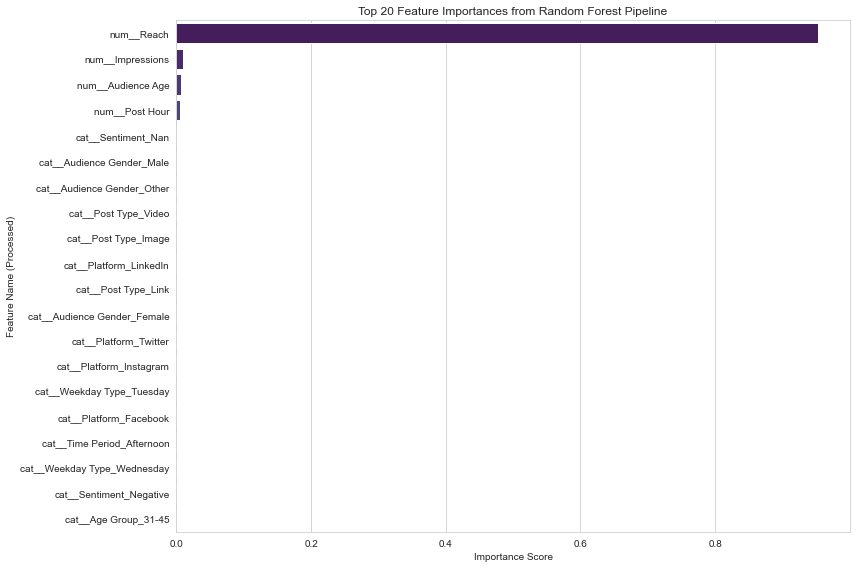


--- Finished Goal 1 Initial Modeling Attempt ---


In [5]:
# Purpose: Split data, create a pipeline combining the preprocessor and the model, train, evaluate, and show feature importances.

# Initialize variables that should be defined in this cell if successful
X_train, X_test, y_train, y_test = None, None, None, None
full_pipeline = None
y_pred_rf = None
X = pd.DataFrame() # Initialize X as empty df
y = pd.Series(dtype=float) # Initialize y as empty Series


# Check if prerequisite variables and data are ready
if not data_fe.empty and preprocessor is not None and final_feature_columns_for_X:
    print("\n--- Goal 1: Predicting Engagement Rate (Using Processed Features) ---")

    # --- Prepare Data (Select final features and target) ---
    try:
        # Ensure all selected columns exist AND have had NaNs handled appropriately if numeric conversion was done in cell 9
        valid_cols = [col for col in final_feature_columns_for_X if col in data_fe.columns]
        if len(valid_cols) != len(final_feature_columns_for_X):
            print(f"Warning: Missing some feature columns expected for X: {set(final_feature_columns_for_X) - set(valid_cols)}")
        X = data_fe[valid_cols].copy() # Use only valid cols and create a copy

        # Handle potential NaNs introduced by numeric coercion in cell 9, e.g., by imputation
        numeric_cols_in_X = [col for col in numerical_features if col in X.columns]
        if numeric_cols_in_X:
             for col in numeric_cols_in_X:
                  if X[col].isnull().any():
                       median_val = X[col].median()
                       X[col].fillna(median_val, inplace=True)
                       print(f"Imputed NaNs in numeric column '{col}' with median ({median_val:.2f}).")

        if target_variable in data_fe.columns:
             y = data_fe[target_variable].copy()
             # Align X and y after potential NaN handling/dropping
             common_index = X.index.intersection(y.index)
             X = X.loc[common_index]
             y = y.loc[common_index]
             print(f"Shape of X after NaN handling & alignment: {X.shape}")
             print(f"Shape of y after NaN handling & alignment: {y.shape}")

             if X.empty or y.empty:
                  raise ValueError("X or y became empty after NaN handling or alignment.")

        else:
             raise ValueError(f"Target variable '{target_variable}' not found in data_fe.")


        # Display sample of X before split to see raw data types
        print("\nSample of X before splitting and preprocessing:")
        print(X.head())
        print("\nInfo of X before splitting:")
        X.info()

        # --- Train-Test Split ---
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        print(f"\nTrain shapes: X_train={X_train.shape}, y_train={y_train.shape}")
        print(f"Test shapes:  X_test={X_test.shape}, y_test={y_test.shape}")

        # --- Model: Random Forest Regressor within a Pipeline ---
        print("\n--- Setting up Random Forest Regressor Pipeline ---")
        rf_model = RandomForestRegressor(n_estimators=100,
                                       random_state=42,
                                       n_jobs=-1,
                                       max_depth=15,
                                       min_samples_leaf=10,
                                       max_features=0.5)

        full_pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('regressor', rf_model)
        ])

        print("\nFitting the full pipeline (preprocessor + RandomForest)... This might take some time...")
        try:
            full_pipeline.fit(X_train, y_train)
            print("Pipeline fitted successfully.")

            # --- Evaluate ---
            print("\nEvaluating the pipeline on the test set...")
            y_pred_rf = full_pipeline.predict(X_test)

            r2_rf = r2_score(y_test, y_pred_rf)
            rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
            print(f"Random Forest Pipeline R-squared (Test): {r2_rf:.4f}")
            print(f"Random Forest Pipeline RMSE (Test): {rmse_rf:.4f}")

            # --- Feature Importance (Extracting from Pipeline) ---
            print("\nExtracting Feature Importances from the fitted pipeline...")
            try:
                preprocessor_fitted = full_pipeline.named_steps['preprocessing']
                regressor_fitted = full_pipeline.named_steps['regressor']
                feature_names_out = preprocessor_fitted.get_feature_names_out()
                importances_values = regressor_fitted.feature_importances_

                importances_df = pd.DataFrame({'feature': feature_names_out, 'importance': importances_values})
                importances_df = importances_df.sort_values('importance', ascending=False).reset_index(drop=True)

                print(f"Total features processed by the pipeline: {len(importances_df)}")
                print("\nTop 20 Feature Importances:")
                print(importances_df.head(20))

                top_n = 20
                plt.figure(figsize=(12, 8))
                sns.barplot(x='importance', y='feature', data=importances_df.head(top_n), palette='viridis')
                plt.title(f'Top {top_n} Feature Importances from Random Forest Pipeline')
                plt.xlabel('Importance Score')
                plt.ylabel('Feature Name (Processed)')
                plt.tight_layout()
                plt.show()

            except AttributeError as ae:
                 print(f"Could not get feature names using get_feature_names_out(): {ae}. Check scikit-learn version (needs >= 1.0).")
            except Exception as e:
                 print(f"Could not extract or plot feature importances: {e}")
                 traceback.print_exc()

        except MemoryError as me:
             print(f"\nMemoryError during pipeline fitting: {me}. The dataset might be too large for available RAM.")
             print("Consider reducing TF-IDF max_features, using sparse matrices, or sampling the data.")
             full_pipeline = None # Ensure pipeline is None if failed
             y_pred_rf = None
        except ValueError as ve:
             print(f"\nValueError during pipeline fitting: {ve}")
             print("Check data types and for unexpected values (e.g., NaNs not handled, non-numeric in numeric columns).")
             traceback.print_exc()
             full_pipeline = None
             y_pred_rf = None
        except Exception as e:
             print(f"\nAn unexpected error occurred during pipeline processing: {e}")
             traceback.print_exc()
             full_pipeline = None
             y_pred_rf = None

    except KeyError as ke:
        print(f"\nKeyError selecting columns for X: {ke}. A column in 'final_feature_columns_for_X' is missing from 'data_fe'.")
        print(f"Columns in data_fe: {list(data_fe.columns)}")
        print(f"Columns expected for X: {final_feature_columns_for_X}")
        # Reset key variables if data prep failed
        X, y, X_train, X_test, y_train, y_test, full_pipeline, y_pred_rf = pd.DataFrame(), pd.Series(dtype=float), None, None, None, None, None, None
    except ValueError as ve:
        print(f"\nValueError during data preparation or splitting: {ve}")
        traceback.print_exc()
        X, y, X_train, X_test, y_train, y_test, full_pipeline, y_pred_rf = pd.DataFrame(), pd.Series(dtype=float), None, None, None, None, None, None
    except Exception as e:
        print(f"\nAn unexpected error occurred preparing data or splitting: {e}")
        traceback.print_exc()
        X, y, X_train, X_test, y_train, y_test, full_pipeline, y_pred_rf = pd.DataFrame(), pd.Series(dtype=float), None, None, None, None, None, None

else:
    print("\nSkipping Goal 1 modeling: Prerequisite check failed (data empty, preprocessor not defined, or feature list empty).")
    # Ensure key variables are None or empty if skipped
    X, y, X_train, X_test, y_train, y_test, full_pipeline, y_pred_rf = pd.DataFrame(), pd.Series(dtype=float), None, None, None, None, None, None


# This print statement is now correctly placed *after* the main if/else block
print("\n--- Finished Goal 1 Initial Modeling Attempt ---")


--- Starting Deeper Evaluation (Cell 11) --- 

--- 1. Correlation Matrix (Original Numerical Features vs Target) ---


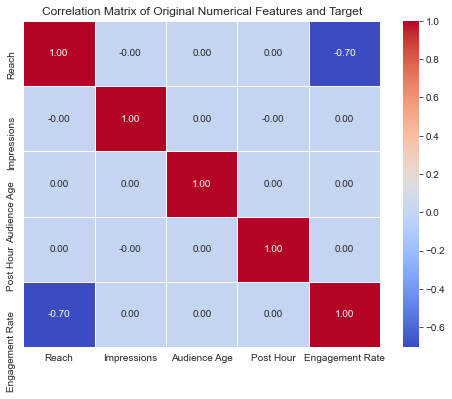


--- 2. Detailed Evaluation Metrics (Random Forest Pipeline on Test Set) ---
R-squared (R2):  0.6916
Mean Absolute Error (MAE): 0.1426 (Avg error in 'Engagement Rate' units)
Mean Squared Error (MSE):  0.0448
Root Mean Squared Error (RMSE): 0.2118 (Std Dev of residuals in 'Engagement Rate' units)

--- 3. Regression Evaluation Plots --- 


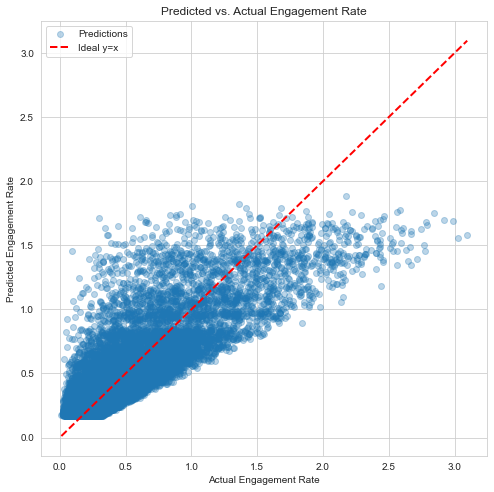

Interpretation: Points should ideally cluster tightly around the red dashed line (y=x).


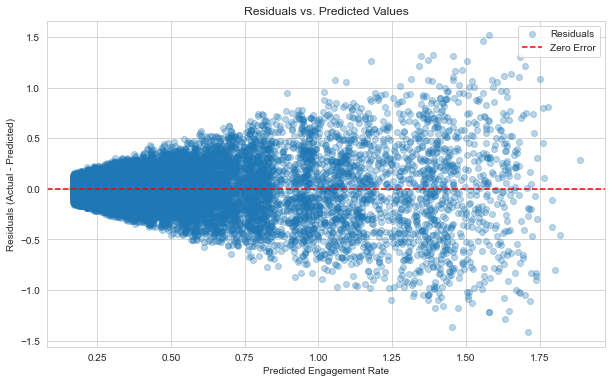

Interpretation: Look for random scatter around the horizontal red line (y=0).
Patterns (like a funnel shape or curve) might indicate issues like non-linearity or heteroscedasticity.


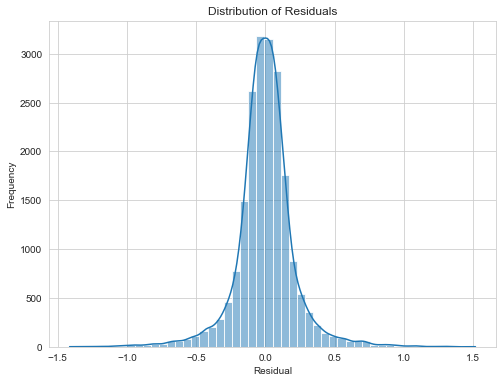

Interpretation: Ideally, residuals should be normally distributed around zero.

--- 4. Cross-Validation (Estimating Generalization Performance) ---
Running 5-Fold Cross-Validation (using negative RMSE)... This may take a while.
Cross-Validation RMSE Scores: [0.21021782 0.20949257 0.21050853 0.20622293 0.20863241]
Mean CV RMSE: 0.2090
Standard Deviation CV RMSE: 0.0015


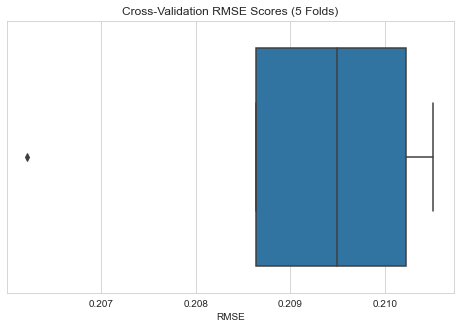

Interpretation: Box plot shows the distribution of performance across different data folds.
Lower mean and smaller std dev are desirable.

--- 5. Learning Curves (Diagnosing Bias/Variance) ---
Generating learning curves... This might take some time.


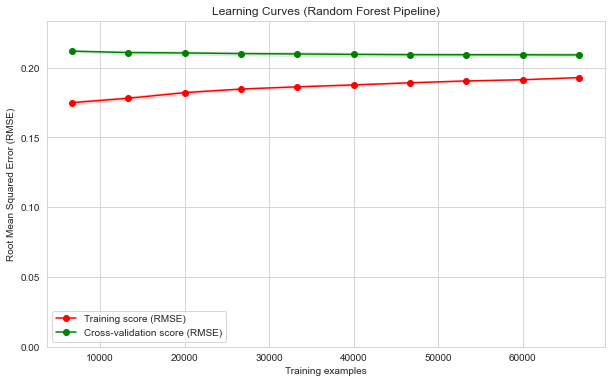

Interpretation:
- High gap between curves: Potential overfitting (high variance). Needs regularization, more data, or simpler model.
- Both curves converge at high error: Potential underfitting (high bias). Needs more complex model or better features.
- Curves close and low error: Good fit.


In [6]:
# Purpose: Evaluate the current model more thoroughly, check assumptions, assess generalization,
#          and prepare for tuning/comparison.

# Check if necessary variables were successfully created in the previous cell
# Use a more targeted check - do we have a fitted pipeline and test data?
evaluation_possible = False
if 'full_pipeline' in locals() and full_pipeline is not None and \
   'X_test' in locals() and X_test is not None and \
   'y_test' in locals() and y_test is not None and \
   'y_pred_rf' in locals() and y_pred_rf is not None and \
   'X' in locals() and not X.empty and \
   'y' in locals() and not y.empty and \
   'data_fe' in locals() and not data_fe.empty:
    print("\n--- Starting Deeper Evaluation (Cell 11) --- ")
    evaluation_possible = True
else:
    print("\n--- Skipping Deeper Evaluation (Cell 11) ---")
    print("Reason: Required variables (pipeline, test data, predictions, full data) from Cell 10 were not successfully created or are missing.")
    # Print which specific variables might be missing or None/Empty
    missing_eval_vars = []
    if 'full_pipeline' not in locals() or full_pipeline is None: missing_eval_vars.append('full_pipeline')
    if 'X_test' not in locals() or X_test is None: missing_eval_vars.append('X_test')
    if 'y_test' not in locals() or y_test is None: missing_eval_vars.append('y_test')
    if 'y_pred_rf' not in locals() or y_pred_rf is None: missing_eval_vars.append('y_pred_rf')
    if 'X' not in locals() or X.empty: missing_eval_vars.append('X (full feature set)')
    if 'y' not in locals() or y.empty: missing_eval_vars.append('y (full target)')
    if 'data_fe' not in locals() or data_fe.empty: missing_eval_vars.append('data_fe')
    if missing_eval_vars:
        print(f"Specifically missing or invalid: {missing_eval_vars}")


if evaluation_possible:

    # === 1. Correlation Matrix (on Original Numerical Features) ===
    print("\n--- 1. Correlation Matrix (Original Numerical Features vs Target) ---")
    original_num_cols_for_corr = [col for col in ['Reach', 'Impressions', 'Audience Age', 'Post Hour', target_variable] if col in data_fe.columns]

    if len(original_num_cols_for_corr) > 1:
        numeric_df_corr = data_fe[original_num_cols_for_corr].apply(pd.to_numeric, errors='coerce')
        numeric_df_corr.dropna(inplace=True)

        if not numeric_df_corr.empty and numeric_df_corr.shape[1] > 1:
            plt.figure(figsize=(8, 6))
            correlation_matrix = numeric_df_corr.corr()
            sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
            plt.title('Correlation Matrix of Original Numerical Features and Target')
            plt.show()
        else:
            print("Could not generate correlation matrix: Data became empty after numeric conversion/dropna.")
    else:
        print("Could not generate correlation matrix: Not enough original numerical/target columns found.")
        print(f"Columns checked: {original_num_cols_for_corr}")

    # === 2. Detailed Evaluation Metrics (from previous prediction y_pred_rf) ===
    print("\n--- 2. Detailed Evaluation Metrics (Random Forest Pipeline on Test Set) ---")
    mae = mean_absolute_error(y_test, y_pred_rf)
    mse = mean_squared_error(y_test, y_pred_rf)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_rf)

    print(f"R-squared (R2):  {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f} (Avg error in '{target_variable}' units)")
    print(f"Mean Squared Error (MSE):  {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f} (Std Dev of residuals in '{target_variable}' units)")

    # === 3. Regression Evaluation Plots ===
    print("\n--- 3. Regression Evaluation Plots --- ")

    # a) Predicted vs. Actual Plot
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_pred_rf, alpha=0.3, label='Predictions')
    # Plot y=x line only if y_test is not empty
    if not y_test.empty:
         min_val = min(y_test.min(), y_pred_rf.min())
         max_val = max(y_test.max(), y_pred_rf.max())
         plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal y=x')
    plt.xlabel("Actual Engagement Rate")
    plt.ylabel("Predicted Engagement Rate")
    plt.title("Predicted vs. Actual Engagement Rate")
    plt.legend()
    plt.grid(True)
    plt.show()
    print("Interpretation: Points should ideally cluster tightly around the red dashed line (y=x).")

    # b) Residuals vs. Predicted Plot
    residuals = y_test - y_pred_rf
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred_rf, residuals, alpha=0.3, label='Residuals')
    plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
    plt.xlabel("Predicted Engagement Rate")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.title("Residuals vs. Predicted Values")
    plt.legend()
    plt.grid(True)
    plt.show()
    print("Interpretation: Look for random scatter around the horizontal red line (y=0).")
    print("Patterns (like a funnel shape or curve) might indicate issues like non-linearity or heteroscedasticity.")

    # c) Histogram/KDE of Residuals
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True, bins=50)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title("Distribution of Residuals")
    plt.grid(True)
    plt.show()
    print("Interpretation: Ideally, residuals should be normally distributed around zero.")

    # === 4. Cross-Validation ===
    print("\n--- 4. Cross-Validation (Estimating Generalization Performance) ---")
    print("Running 5-Fold Cross-Validation (using negative RMSE)... This may take a while.")
    try:
        # Ensure X and y used for CV are the versions aligned after potential NaN handling in cell 10
        if not X.empty and not y.empty:
            cv_scores_rmse = cross_val_score(full_pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
            cv_scores_rmse = -cv_scores_rmse

            print(f"Cross-Validation RMSE Scores: {cv_scores_rmse}")
            print(f"Mean CV RMSE: {np.mean(cv_scores_rmse):.4f}")
            print(f"Standard Deviation CV RMSE: {np.std(cv_scores_rmse):.4f}")

            plt.figure(figsize=(8, 5))
            sns.boxplot(x=cv_scores_rmse)
            plt.title('Cross-Validation RMSE Scores (5 Folds)')
            plt.xlabel('RMSE')
            plt.show()
            print("Interpretation: Box plot shows the distribution of performance across different data folds.")
            print("Lower mean and smaller std dev are desirable.")
        else:
            print("Skipping CV: X or y data for cross-validation is empty.")

    except Exception as e:
        print(f"Cross-validation failed: {e}")
        traceback.print_exc()


    # === 5. Learning Curves ===
    print("\n--- 5. Learning Curves (Diagnosing Bias/Variance) ---")
    print("Generating learning curves... This might take some time.")
    try:
        if not X.empty and not y.empty:
            train_sizes_abs, train_scores, validation_scores = learning_curve(
                estimator=full_pipeline,
                X=X,
                y=y,
                train_sizes=np.linspace(0.1, 1.0, 10),
                cv=3,
                scoring='neg_root_mean_squared_error',
                n_jobs=-1,
                shuffle=True, # Shuffle data for each cv split
                random_state=42
            )

            train_scores_mean = -np.mean(train_scores, axis=1)
            train_scores_std = np.std(train_scores, axis=1)
            validation_scores_mean = -np.mean(validation_scores, axis=1)
            validation_scores_std = np.std(validation_scores, axis=1)

            plt.figure(figsize=(10, 6))
            plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                             train_scores_mean + train_scores_std, alpha=0.1, color="r")
            plt.fill_between(train_sizes_abs, validation_scores_mean - validation_scores_std,
                             validation_scores_mean + validation_scores_std, alpha=0.1, color="g")
            plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r", label="Training score (RMSE)")
            plt.plot(train_sizes_abs, validation_scores_mean, 'o-', color="g", label="Cross-validation score (RMSE)")

            plt.title("Learning Curves (Random Forest Pipeline)")
            plt.xlabel("Training examples")
            plt.ylabel("Root Mean Squared Error (RMSE)")
            plt.legend(loc="best")
            plt.grid(True)
            # Dynamic Y-axis limits
            plot_min_y = 0
            plot_max_y = max(np.max(train_scores_mean + train_scores_std), np.max(validation_scores_mean + validation_scores_std)) * 1.1
            plt.ylim(bottom=plot_min_y, top=plot_max_y if not np.isnan(plot_max_y) else None) # Handle potential NaN in max
            plt.show()

            print("Interpretation:")
            print("- High gap between curves: Potential overfitting (high variance). Needs regularization, more data, or simpler model.")
            print("- Both curves converge at high error: Potential underfitting (high bias). Needs more complex model or better features.")
            print("- Curves close and low error: Good fit.")
        else:
            print("Skipping Learning Curves: X or y data is empty.")

    except Exception as e:
        print(f"Learning curve generation failed: {e}")
        traceback.print_exc()

In [7]:
# Purpose: Train a different relevant model using the same preprocessing,
#          and compare its performance against previous models using cross-validation.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import time # To time operations
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score

# --- Try importing LightGBM ---
try:
    from lightgbm import LGBMRegressor
    lightgbm_installed = True
except ImportError:
    print("Warning: LightGBM not found. Please install it using 'pip install lightgbm'")
    print("Skipping LightGBM model training and comparison.")
    lightgbm_installed = False

# --- Check if prerequisite variables are available ---
prereqs_available = False
required_vars_cell12 = [
    'preprocessor', 'X', 'y', 'X_train', 'y_train', 'X_test', 'y_test',
    'full_pipeline', # Initial RF pipeline
    'ridge_pipeline' # Ridge pipeline from cell 11
]
# Also check if tuning results are available (optional but good to include)
tuned_rf_pipeline = locals().get('best_pipeline', None) # Get tuned RF if it exists

if all(var in locals() and locals()[var] is not None for var in required_vars_cell12) and not X.empty:
    print("\n--- Prerequisites for Model Comparison Met ---")
    prereqs_available = True
else:
    print("\n--- Prerequisites for Model Comparison NOT Met ---")
    print("Reason: Required variables (preprocessor, data, initial RF/Ridge pipelines) from previous cells are missing or invalid.")
    missing_comp_vars = [var for var in required_vars_cell12 if var not in locals() or locals()[var] is None]
    if 'X' in locals() and X.empty: missing_comp_vars.append("X (empty)")
    if missing_comp_vars:
         print(f"Specifically missing or invalid: {missing_comp_vars}")


# --- Proceed only if LightGBM is installed and prerequisites are met ---
if lightgbm_installed and prereqs_available:
    print("\n--- 1. Setting up LightGBM Pipeline ---")
    # Use the SAME preprocessor
    lgbm_pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('regressor', LGBMRegressor(random_state=42, n_jobs=-1)) # Using default LGBM params initially
    ])

    print("\n--- 2. Training LightGBM Pipeline ---")
    try:
        start_time = time.time()
        lgbm_pipeline.fit(X_train, y_train)
        lgbm_train_time = time.time() - start_time
        print(f"LightGBM pipeline fitted successfully in {lgbm_train_time:.2f} seconds.")

        print("\n--- 3. Evaluating LightGBM on Test Set ---")
        start_time = time.time()
        y_pred_lgbm = lgbm_pipeline.predict(X_test)
        lgbm_predict_time = time.time() - start_time

        r2_lgbm = r2_score(y_test, y_pred_lgbm)
        rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
        mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)

        print(f"LightGBM Pipeline Performance (Test Set):")
        print(f"  R-squared (R2): {r2_lgbm:.4f}")
        print(f"  RMSE:           {rmse_lgbm:.4f}")
        print(f"  MAE:            {mae_lgbm:.4f}")
        print(f"  Prediction time: {lgbm_predict_time:.4f} seconds")
        print("\nNote: This is performance with default hyperparameters. Tuning LGBM could improve results.")

    except Exception as e:
        print(f"\nError during LightGBM pipeline fitting or evaluation: {e}")
        traceback.print_exc()
        lgbm_pipeline = None # Mark as failed

    # --- 4. Cross-Validation Comparison ---
    print("\n--- 4. Cross-Validation Comparison (RMSE) ---")
    print("Running 5-Fold CV for all models... This may take significant time.")

    models_to_compare = {}
    # Use the initial RF pipeline
    models_to_compare['RandomForest_Initial'] = full_pipeline

    # Include the tuned RF pipeline if available
    if tuned_rf_pipeline is not None:
         print("Including tuned Random Forest pipeline in CV comparison.")
         models_to_compare['RandomForest_Tuned'] = tuned_rf_pipeline
    else:
         print("Tuned Random Forest pipeline ('best_pipeline') not found, comparing against initial RF only.")

    # Include Ridge
    models_to_compare['Ridge'] = ridge_pipeline

    # Include LGBM if it fitted successfully
    if 'lgbm_pipeline' in locals() and lgbm_pipeline is not None:
        models_to_compare['LightGBM_Initial'] = lgbm_pipeline
    else:
        print("LightGBM pipeline failed to fit, excluding from CV comparison.")


    cv_results_rmse = {}
    cv_times = {}

    # Perform CV for each model
    for name, model in models_to_compare.items():
        print(f"  Running CV for: {name}...")
        try:
            start_time = time.time()
            # Use the full dataset X, y for robust evaluation
            scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
            cv_results_rmse[name] = -scores # Store positive RMSE scores
            cv_times[name] = time.time() - start_time
            print(f"    Mean CV RMSE: {np.mean(cv_results_rmse[name]):.4f} (+/- {np.std(cv_results_rmse[name]):.4f})")
            print(f"    CV Time: {cv_times[name]:.2f} seconds")
        except Exception as e:
            print(f"    CV failed for {name}: {e}")
            # Optionally remove the model from results if CV failed
            # cv_results_rmse.pop(name, None)

    # --- 5. Visualize CV Comparison ---
    print("\n--- 5. Visualizing Cross-Validation Comparison ---")
    if cv_results_rmse: # Check if there are any results to plot
        # Create a DataFrame for plotting
        cv_results_df = pd.DataFrame(cv_results_rmse)

        plt.figure(figsize=(12, 7))
        sns.boxplot(data=cv_results_df, palette="viridis")
        plt.title('Model Comparison based on 5-Fold Cross-Validation RMSE')
        plt.ylabel('Root Mean Squared Error (RMSE)')
        plt.xlabel('Model')
        plt.xticks(rotation=15) # Rotate labels slightly if needed
        plt.grid(axis='y', linestyle='--')
        plt.show()

        print("\nInterpretation:")
        print("- Lower box indicates better average performance (lower mean RMSE).")
        print("- Shorter box indicates more consistent performance across folds.")
        print("- Consider both the median line and the spread of the box/whiskers.")

    else:
        print("No successful cross-validation results to visualize.")


    print("\n--- Conclusion on Model Comparison ---")
    print("Based on the cross-validation results (and potentially test set scores):")
    if cv_results_rmse:
        # Find model with lowest mean CV RMSE
        best_cv_model = min(cv_results_rmse, key=lambda k: np.mean(cv_results_rmse[k]))
        best_mean_rmse = np.mean(cv_results_rmse[best_cv_model])
        print(f"- '{best_cv_model}' showed the best average performance in cross-validation (Mean RMSE: {best_mean_rmse:.4f}).")
    print("- Remember that the LightGBM model used default parameters; tuning it could further improve its score.")
    print("- Also consider training time, prediction time, and interpretability when making a final choice for deployment.")



--- Prerequisites for Model Comparison NOT Met ---
Reason: Required variables (preprocessor, data, initial RF/Ridge pipelines) from previous cells are missing or invalid.
Specifically missing or invalid: ['preprocessor', 'X', 'y', 'X_train', 'y_train', 'X_test', 'y_test', 'full_pipeline', 'ridge_pipeline']


In [ ]:
    # === 6. Hyperparameter Tuning (RandomizedSearchCV - Now Running) ===
    print("\n--- 6. Hyperparameter Tuning (Running RandomizedSearchCV) ---")
    print("*** WARNING: This step can take a significant amount of time! ***")

    # Initialize variables to store results
    best_pipeline = None
    best_params = None
    best_score = None

    # Check if prerequisite variables exist
    if 'full_pipeline' in locals() and full_pipeline is not None and \
       'X_train' in locals() and X_train is not None and \
       'y_train' in locals() and y_train is not None:

        # Define parameter grid - MUST use 'step_name__parameter_name' syntax for Pipeline
        # Example: 'regressor__n_estimators' refers to the 'n_estimators' param of the 'regressor' step
        param_dist = {
            'regressor__n_estimators': [100, 200, 300, 400], # Number of trees
            'regressor__max_depth': [10, 15, 20, 30, None], # Max depth of trees
            'regressor__min_samples_leaf': [5, 10, 20, 30], # Min samples at leaf node
            'regressor__min_samples_split': [10, 20, 40, 60], # Min samples to split node
            'regressor__max_features': [0.5, 0.7, 'sqrt', 'log2', 1.0], # Features to consider at each split (1.0 means all)
            # Example tuning TF-IDF (Uncomment carefully - significantly increases search time)
             'preprocessing__text__tfidf__max_df': [0.7, 0.85, 1.0],
             'preprocessing__text__tfidf__min_df': [3, 5, 10],
             'preprocessing__text__tfidf__ngram_range': [(1, 1), (1, 2)], # Uni-grams or bi-grams
        }

        # Set up RandomizedSearchCV
        # n_iter controls how many parameter combinations are tried.
        # Adjust n_iter and cv based on available time.
        n_iterations = 25 # Number of combinations to try
        cv_folds = 3      # Number of cross-validation folds

        print(f"Starting RandomizedSearchCV with n_iter={n_iterations}, cv={cv_folds}...")
        random_search = RandomizedSearchCV(
            full_pipeline, # The *untuned* pipeline with default RF params
            param_distributions=param_dist,
            n_iter=n_iterations,
            cv=cv_folds,
            scoring='neg_root_mean_squared_error', # Optimize for lower RMSE (higher neg_rmse)
            verbose=2, # Show progress details
            random_state=42,
            n_jobs=-1 # Use all available cores
        )

        try:
            # Fit the random search object to the training data
            random_search.fit(X_train, y_train)

            print("\n--- Hyperparameter Tuning Results ---")
            # Access the results
            best_pipeline = random_search.best_estimator_
            best_params = random_search.best_params_
            # Note: best_score_ is the *mean cross-validated score* on the training data
            # It's the negative RMSE in this case. Convert back to positive RMSE.
            best_score = -random_search.best_score_

            print(f"Best Mean Cross-Validated RMSE: {best_score:.4f}")
            print("Best Parameters Found:")
            # Print parameters nicely
            for param, value in best_params.items():
                 print(f"  {param}: {value}")
            print("\nBest estimator pipeline stored in 'best_pipeline' variable.")

        except MemoryError as me:
            print(f"\nMemoryError during RandomizedSearchCV fitting: {me}.")
            print("Try reducing n_iter, cv, max_features in TF-IDF, or using a smaller data sample.")
            best_pipeline, best_params, best_score = None, None, None # Reset results
        except Exception as e:
            print(f"\nAn error occurred during RandomizedSearchCV: {e}")
            traceback.print_exc()
            best_pipeline, best_params, best_score = None, None, None # Reset results

    else:
        print("Skipping Hyperparameter Tuning: Prerequisite variables (untuned pipeline, training data) not available.")


    # Now you can potentially use the 'best_pipeline' for further evaluation on the test set if needed
    if best_pipeline is not None:
         print("\n--- Evaluating Best Tuned Pipeline on Test Set ---")
         try:
              y_pred_best = best_pipeline.predict(X_test)
              r2_best = r2_score(y_test, y_pred_best)
              rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
              print(f"Tuned Pipeline R-squared (Test): {r2_best:.4f}")
              print(f"Tuned Pipeline RMSE (Test): {rmse_best:.4f}")
              # Compare with initial model's RMSE if available
              if 'rmse_rf' in locals():
                   print(f"(Initial Untuned Model Test RMSE was: {rmse_rf:.4f})")
         except Exception as e:
              print(f"Could not evaluate the best pipeline on the test set: {e}")
              traceback.print_exc()
    else:
         print("\nBest pipeline not available for final evaluation on test set (tuning may have failed or was skipped).")



--- 6. Hyperparameter Tuning (Running RandomizedSearchCV) ---
*** WARNING: This step can take a significant amount of time! ***
Starting RandomizedSearchCV with n_iter=25, cv=3...
Fitting 3 folds for each of 25 candidates, totalling 75 fits


In [ ]:
# === 7. Alternative Model Example (Ridge Regression) ===
    print("\n--- 7. Alternative Model Example (Ridge Regression) ---")
    if 'preprocessor' in locals() and preprocessor is not None and X_train is not None:
        ridge_pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('regressor', Ridge(alpha=1.0, random_state=42, solver='auto'))
        ])

        print("Fitting Ridge pipeline...")
        try:
            ridge_pipeline.fit(X_train, y_train)
            y_pred_ridge = ridge_pipeline.predict(X_test)

            r2_ridge = r2_score(y_test, y_pred_ridge)
            rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
            print("\nRidge Regression Pipeline Performance (on Test Set):")
            print(f"R-squared (R2): {r2_ridge:.4f}")
            print(f"RMSE: {rmse_ridge:.4f}")

            print("\nRunning Cross-Validation for Ridge model...")
            if not X.empty and not y.empty:
                 ridge_cv_scores = cross_val_score(ridge_pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
                 ridge_cv_rmse = -np.mean(ridge_cv_scores)
                 print(f"Mean CV RMSE for Ridge: {ridge_cv_rmse:.4f}")
                 print("Note: For fair comparison, Ridge should also be tuned (alpha parameter, potentially others).")
            else:
                 print("Skipping Ridge CV: X or y data is empty.")

        except Exception as e:
            print(f"Fitting or evaluating Ridge pipeline failed: {e}")
            traceback.print_exc()
    else:
         print("Skipping Ridge Model Example: Preprocessor or Training data not available.")

    print("\n--- Finished Deeper Evaluation --- ")